# RQ6: How do conversion rate and click-through rate interact with ad spend to influence sales revenue?
**Dataset:** Marketing and Product Performance Dataset (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
print('Ready.')

Ready.


In [2]:
# ── LOAD DATASET ──────────────────────────────────────────────────────────────
df = pd.read_csv('marketing_and_product_performance.csv')
df = df.dropna(subset=['Revenue_Generated'])

clicks_col      = next((c for c in df.columns if 'click' in c.lower()), None)
impressions_col = next((c for c in df.columns if 'impression' in c.lower()), None)
conversions_col = next((c for c in df.columns if 'conversion' in c.lower()), None)
ad_spend_col    = next((c for c in df.columns if 'spend' in c.lower()), None)
rev_col         = 'Revenue_Generated'

print(f'Clicks: {clicks_col}, Impressions: {impressions_col}, Conversions: {conversions_col}, Ad Spend: {ad_spend_col}')

# Compute CTR and CVR
if clicks_col and impressions_col:
    df['CTR'] = df[clicks_col] / (df[impressions_col] + 1e-9)
    print('CTR computed.')
if conversions_col and clicks_col:
    df['CVR'] = df[conversions_col] / (df[clicks_col] + 1e-9)
    print('CVR computed.')

df.head(3)

Clicks: Clicks, Impressions: None, Conversions: Conversions, Ad Spend: None
CVR computed.


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords,CVR
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable,0.014759
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative,0.894737
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable,0.074732


In [3]:
# ── TABLE 6.1 — Correlation Matrix ───────────────────────────────────────────
corr_cols = [c for c in [clicks_col, impressions_col, conversions_col, ad_spend_col, 'CTR', 'CVR', rev_col] if c and c in df.columns]
corr_matrix = df[corr_cols].corr()

table_61 = corr_matrix[[rev_col]].drop(rev_col).sort_values(rev_col, ascending=False).reset_index()
table_61.columns = ['Feature', 'Correlation_with_Revenue']
table_61['Correlation_with_Revenue'] = table_61['Correlation_with_Revenue'].round(4)
table_61.to_csv('Table_6_1_Correlation_CTR_CVR_Revenue.csv', index=False)
print('Table 6.1 saved.')
table_61

Table 6.1 saved.


,Feature,Correlation_with_Revenue
0,CVR,0.0074
1,Conversions,0.0025
2,Clicks,-0.0071


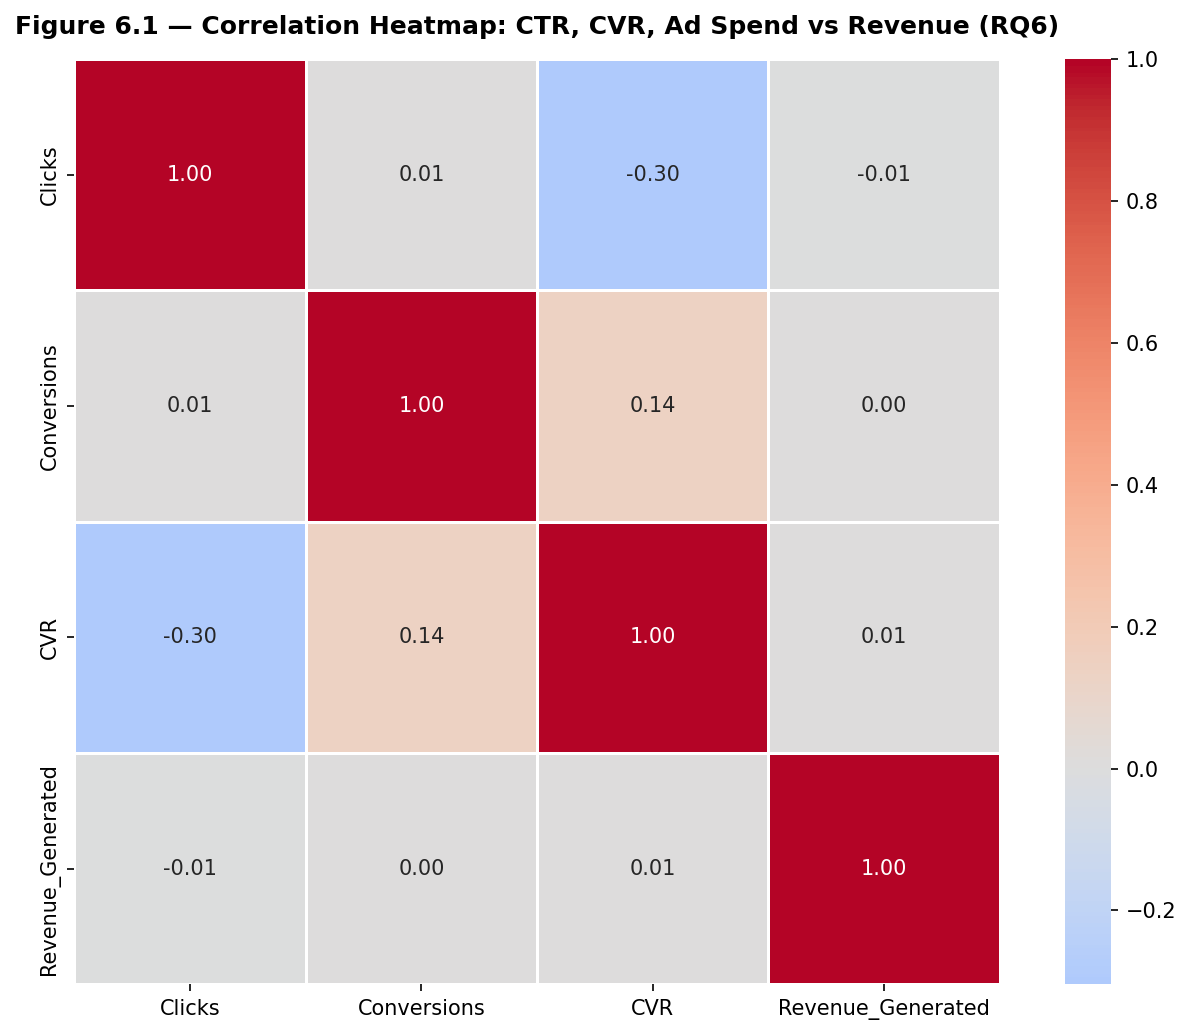

Figure 6.1 saved.


In [4]:
# ── FIGURE 6.1 — Correlation Heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Figure 6.1 — Correlation Heatmap: CTR, CVR, Ad Spend vs Revenue (RQ6)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('Figure_6_1_Correlation_Heatmap.pdf', bbox_inches='tight')
plt.show()
print('Figure 6.1 saved.')

In [5]:
# ── FIGURE 6.2 — CTR × CVR Interaction Scatter ───────────────────────────────
if 'CTR' in df.columns and 'CVR' in df.columns:
    # Bin CVR for color grouping
    df['CVR_Bin'] = pd.qcut(df['CVR'].clip(0, df['CVR'].quantile(0.99)), q=3, labels=['Low CVR','Mid CVR','High CVR'])

    fig, ax = plt.subplots(figsize=(11, 6))
    colors_cvr = {'Low CVR': '#CAF0F8', 'Mid CVR': '#048A81', 'High CVR': '#2E4057'}
    for label, group in df.groupby('CVR_Bin', observed=True):
        ax.scatter(group['CTR'].clip(0, group['CTR'].quantile(0.99)),
                   group[rev_col], label=label, alpha=0.4, s=15, color=colors_cvr[label])
    ax.set_xlabel('Click-Through Rate (CTR)', fontsize=12)
    ax.set_ylabel('Sales Revenue', fontsize=12)
    ax.set_title('Figure 6.2 — CTR × CVR Interaction with Sales Revenue (RQ6)', fontweight='bold')
    ax.legend(title='CVR Group')
    plt.tight_layout()
    plt.savefig('Figure_6_2_CTR_CVR_Revenue_Scatter.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 6.2 saved.')

In [6]:
# ── FIGURE 6.3 — Partial Dependence: Ad Spend bins vs Revenue ────────────────
if ad_spend_col:
    df_clean = df.copy()
    df_clean['Spend_Quartile'] = pd.qcut(df_clean[ad_spend_col], q=4, labels=['Q1','Q2','Q3','Q4'])

    group_means = df_clean.groupby('Spend_Quartile', observed=True).agg(
        Mean_Revenue=(rev_col, 'mean'),
        Mean_CTR=('CTR','mean') if 'CTR' in df_clean.columns else (rev_col,'std'),
        Mean_CVR=('CVR','mean') if 'CVR' in df_clean.columns else (rev_col,'std'),
        Count=(rev_col, 'count')
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    x = range(len(group_means))
    bars = ax1.bar(x, group_means['Mean_Revenue'], color=['#CAF0F8','#54C6EB','#048A81','#2E4057'], width=0.5)
    ax1.set_xticks(x)
    ax1.set_xticklabels(group_means['Spend_Quartile'].astype(str))
    ax1.set_ylabel('Mean Sales Revenue')
    ax1.set_xlabel('Ad Spend Quartile')
    ax1.set_title('Figure 6.3 — Mean Revenue by Ad Spend Quartile with Engagement Metrics (RQ6)', fontweight='bold')
    for bar, val in zip(bars, group_means['Mean_Revenue']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('Figure_6_3_Revenue_by_SpendQuartile.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 6.3 saved.')

## RQ6 Summary
The correlation heatmap (Figure 6.1) shows direct relationships between CTR, CVR, Ad Spend, and Sales Revenue. Figure 6.2 reveals how high CVR amplifies the effect of CTR on revenue. Table 6.1 ranks features by correlation strength with the target.